# Overview of the contents of the validation dataset

The Ice Floe Tracker Validation Dataset contains images randomly sampled from Arctic marginal ice zones. The 9 regions are shown below. The sampling procedure selected center pixels from the region with 15-85% sea ice concentration from the NSIDC Climate Data Record of Sea Ice Concentration. 

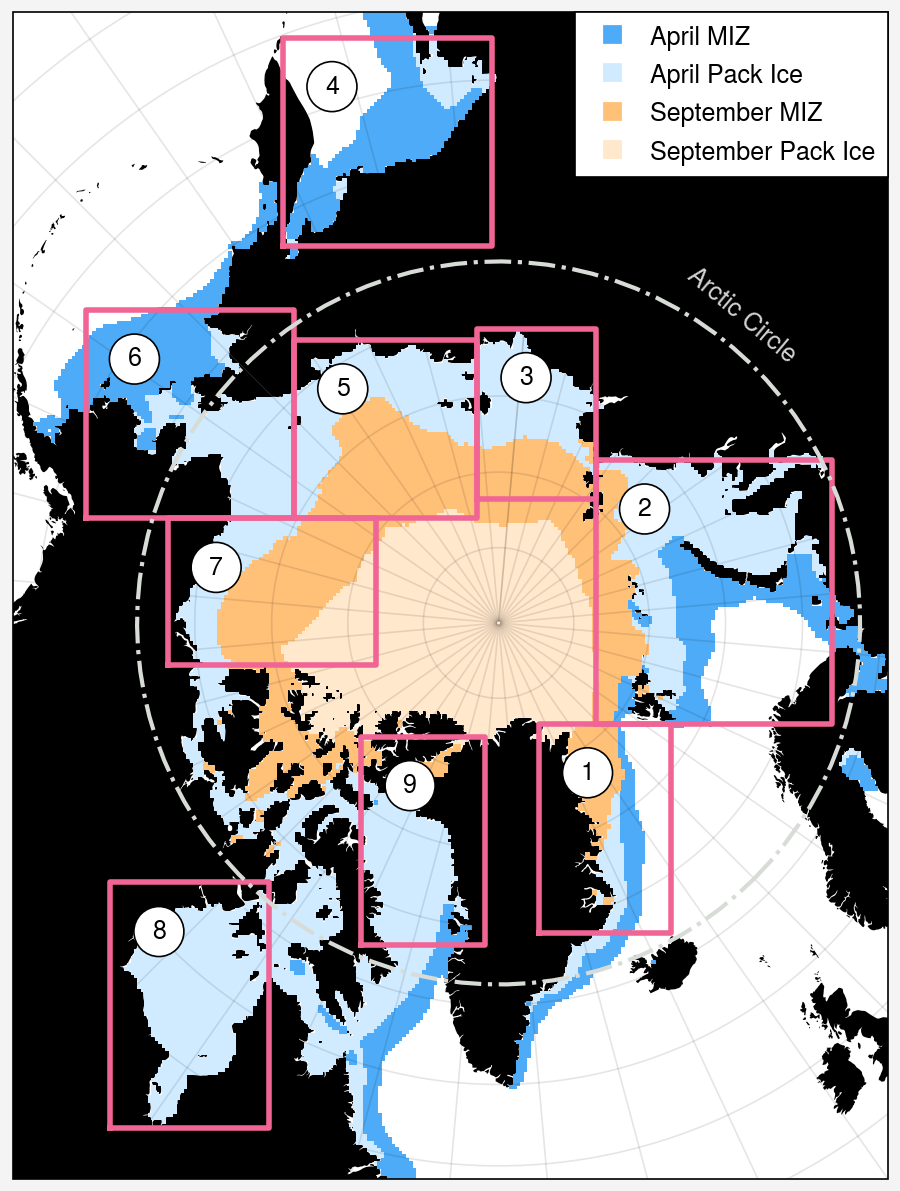

In [3]:
%run ../scripts/plot_locations.py

The time range for each region was defined by the climatology of sea ice fraction (sea ice extent scaled by the ocean area). The number printed below is the latest day of year where the 90th percentile of SIF is over 5%.

greenland_sea 274
barents_kara_seas 274
laptev_sea 274
east_siberian_sea 274
bering_chukchi_seas 236
beaufort_sea 274
baffin_bay 274
hudson_bay 218
sea_of_okhostk 178


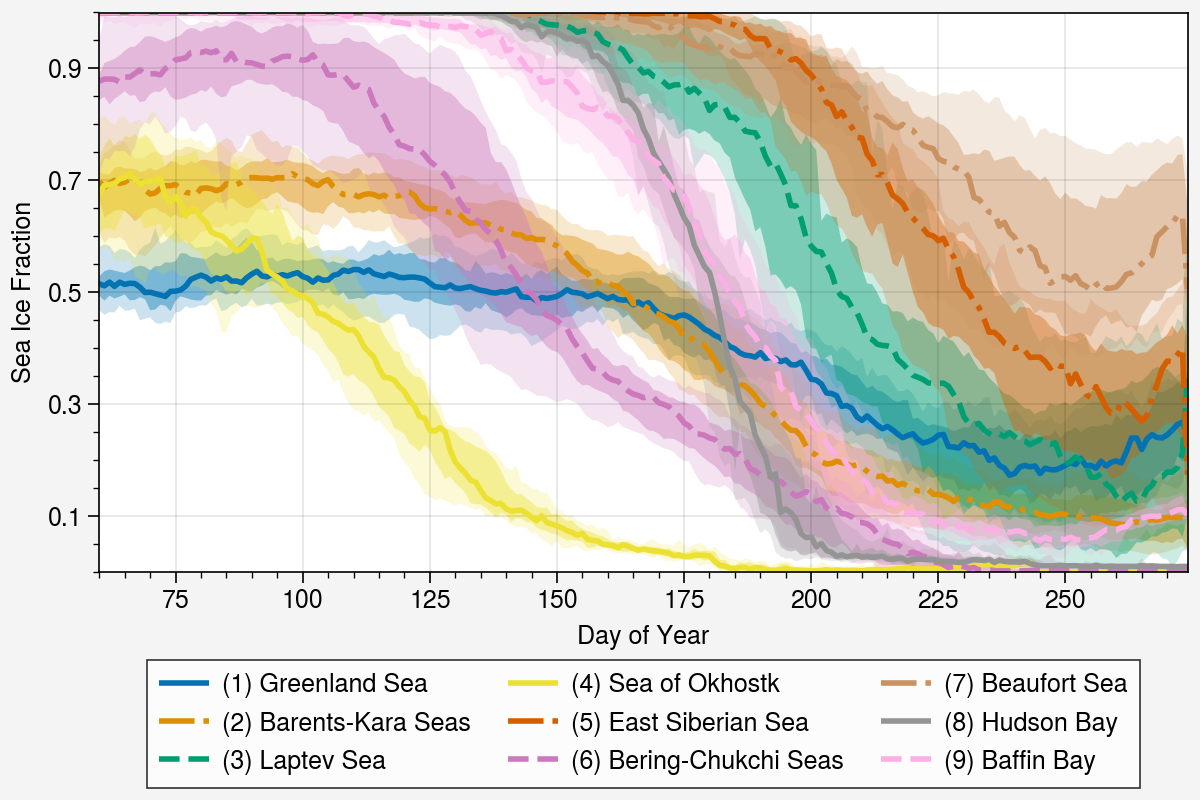

In [5]:
%run ../scripts/plot_sif_climatology.py

The portion of the dataset produced so far contains 378 individual 100 km samples with labeled ice floes, labeled landfast ice, and co-located MASIE sea ice extent images, corresponding to 179 "cases". The contents of the dataset include images such as those below.

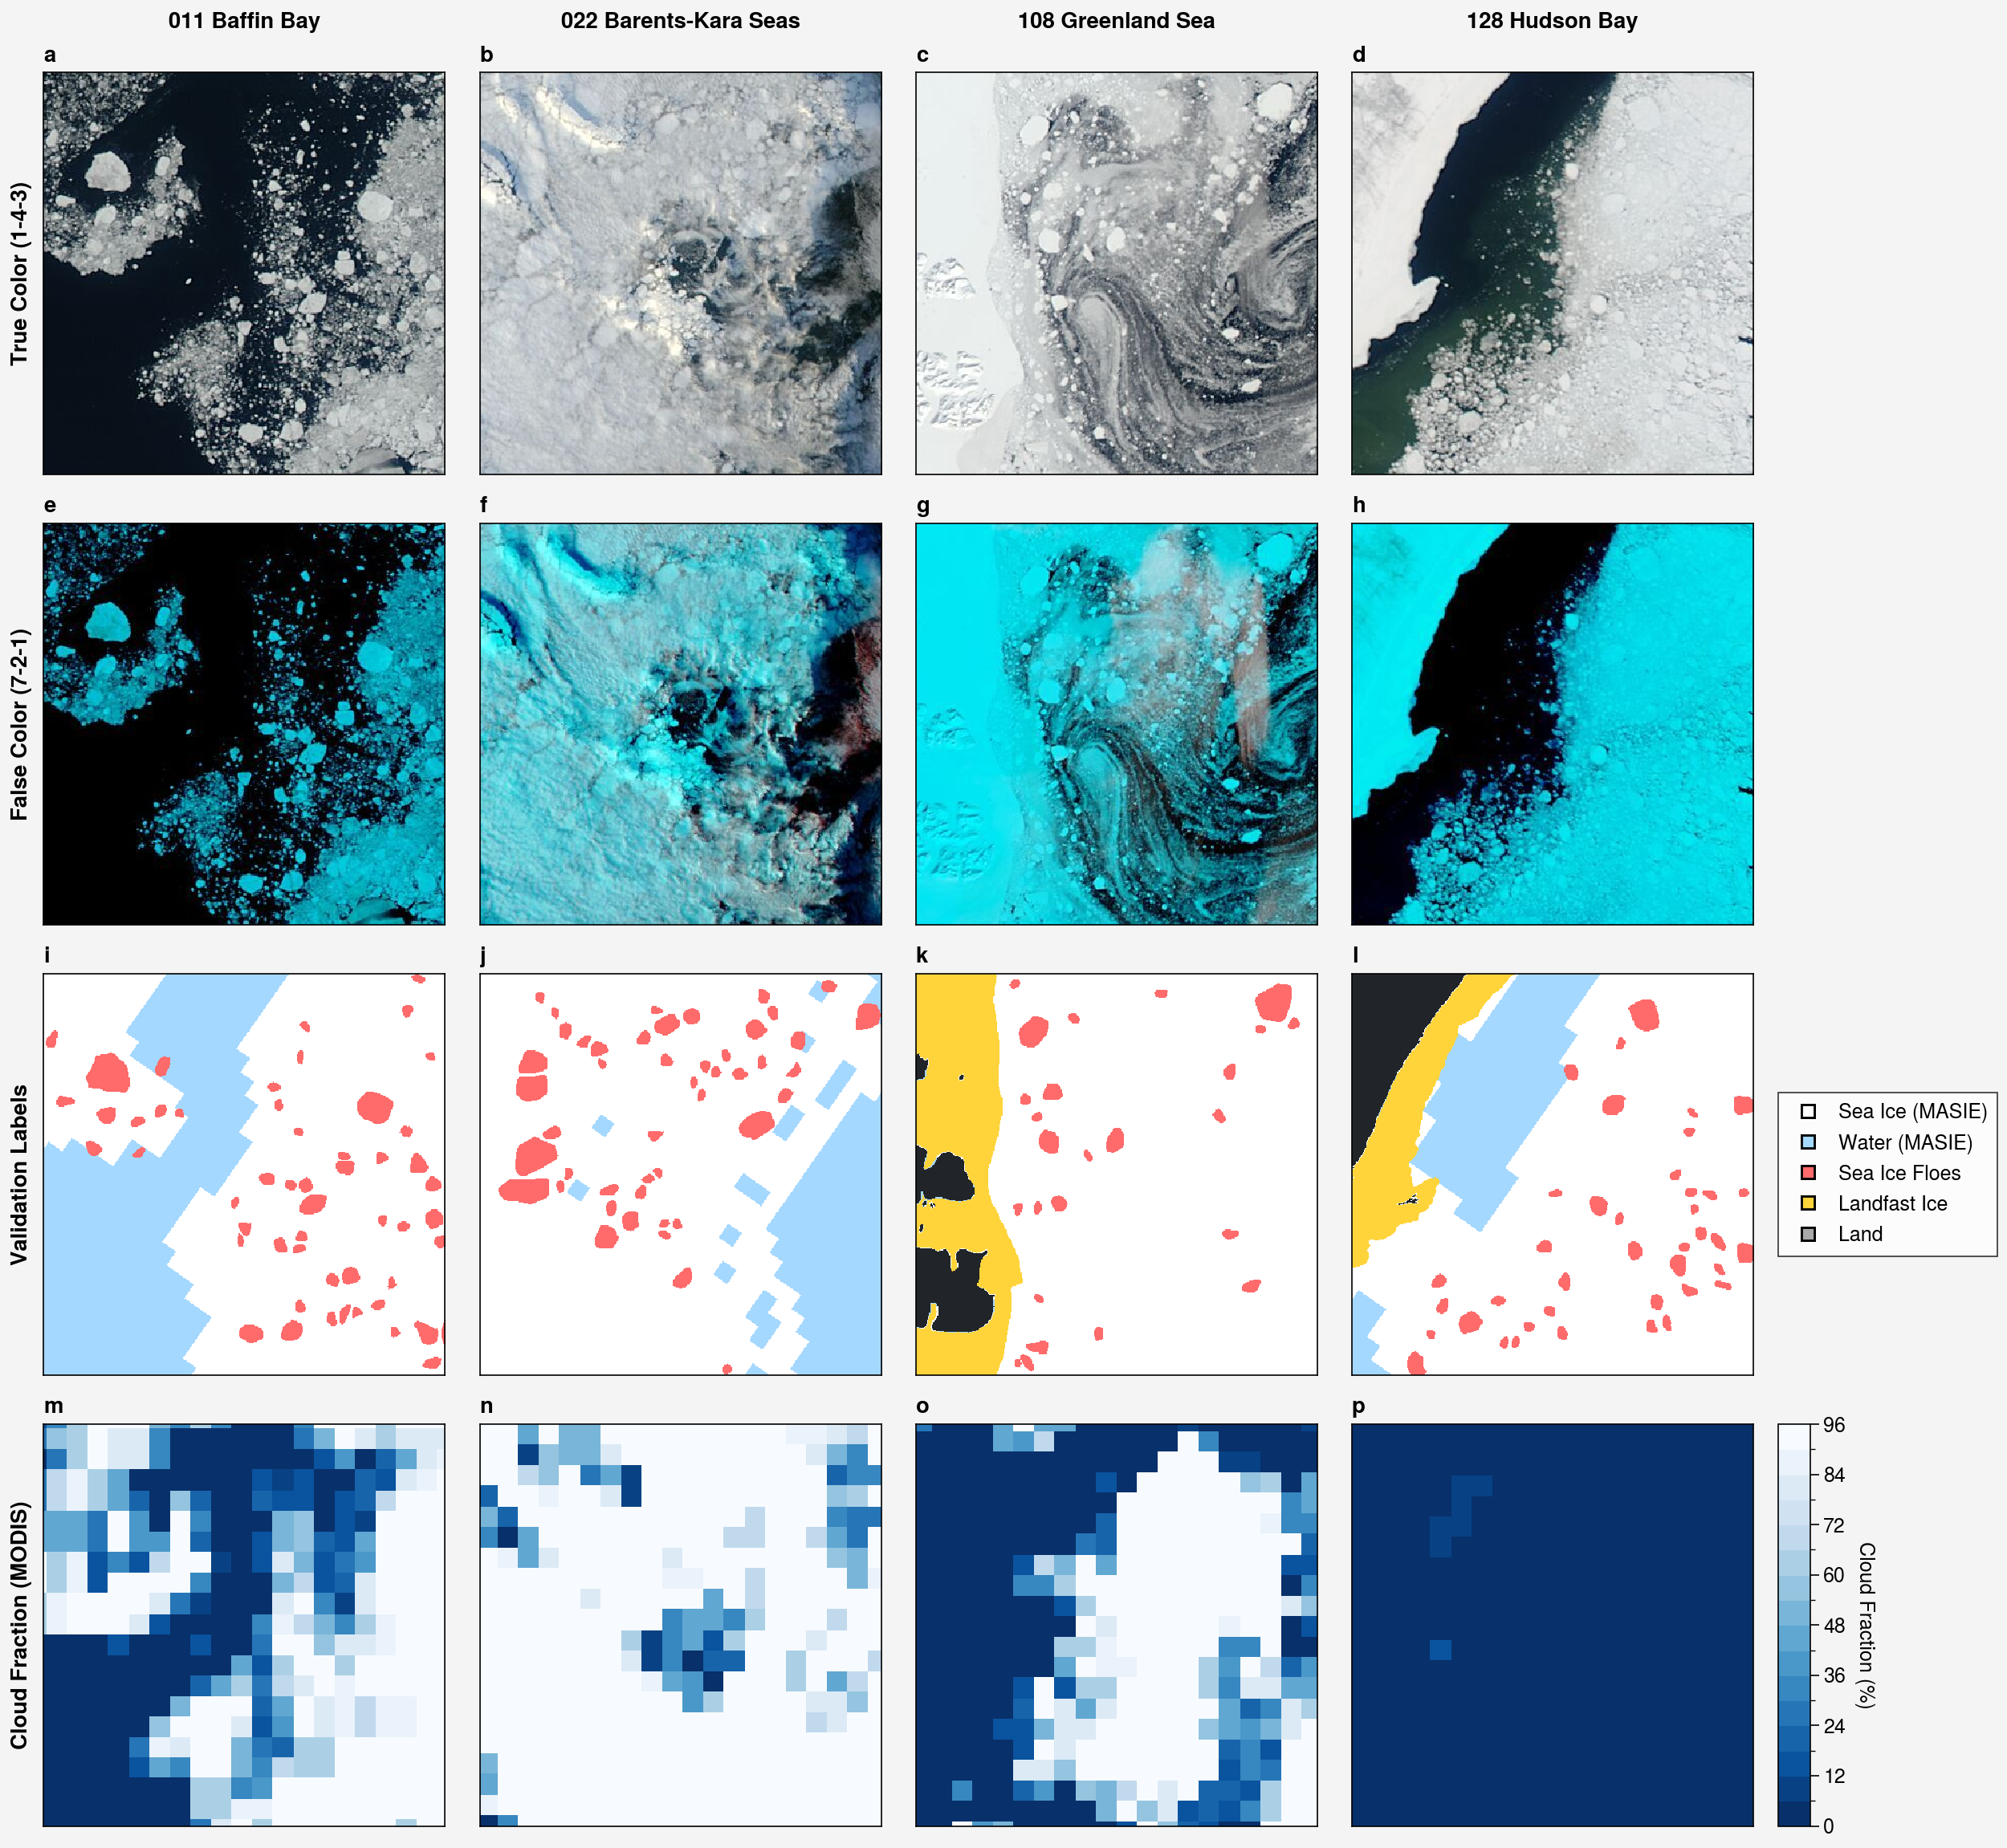

In [6]:
%run ../scripts/plot_dataset_sample.py

The locations of the 100 km sample set is shown in panel (c) below. In the figure, only the data from Aqua are shown, and the color scheme indicates whether any floes are visible in the image. We also see the number of images over the course of the season. Images are evenly distributed within each region's sea ice period, however some regions have earlier end-dates. Thus, we have fewer images as the season progresses. Depending on the time of year, about half of the images have at least one visible floe. This is encouraging, however it masks the issue that the size, area, and number of visible floes varies quite a lot. From the FSD, we can see the expected decrease in number with size, and the relative paucity of floes larger than 10 km.

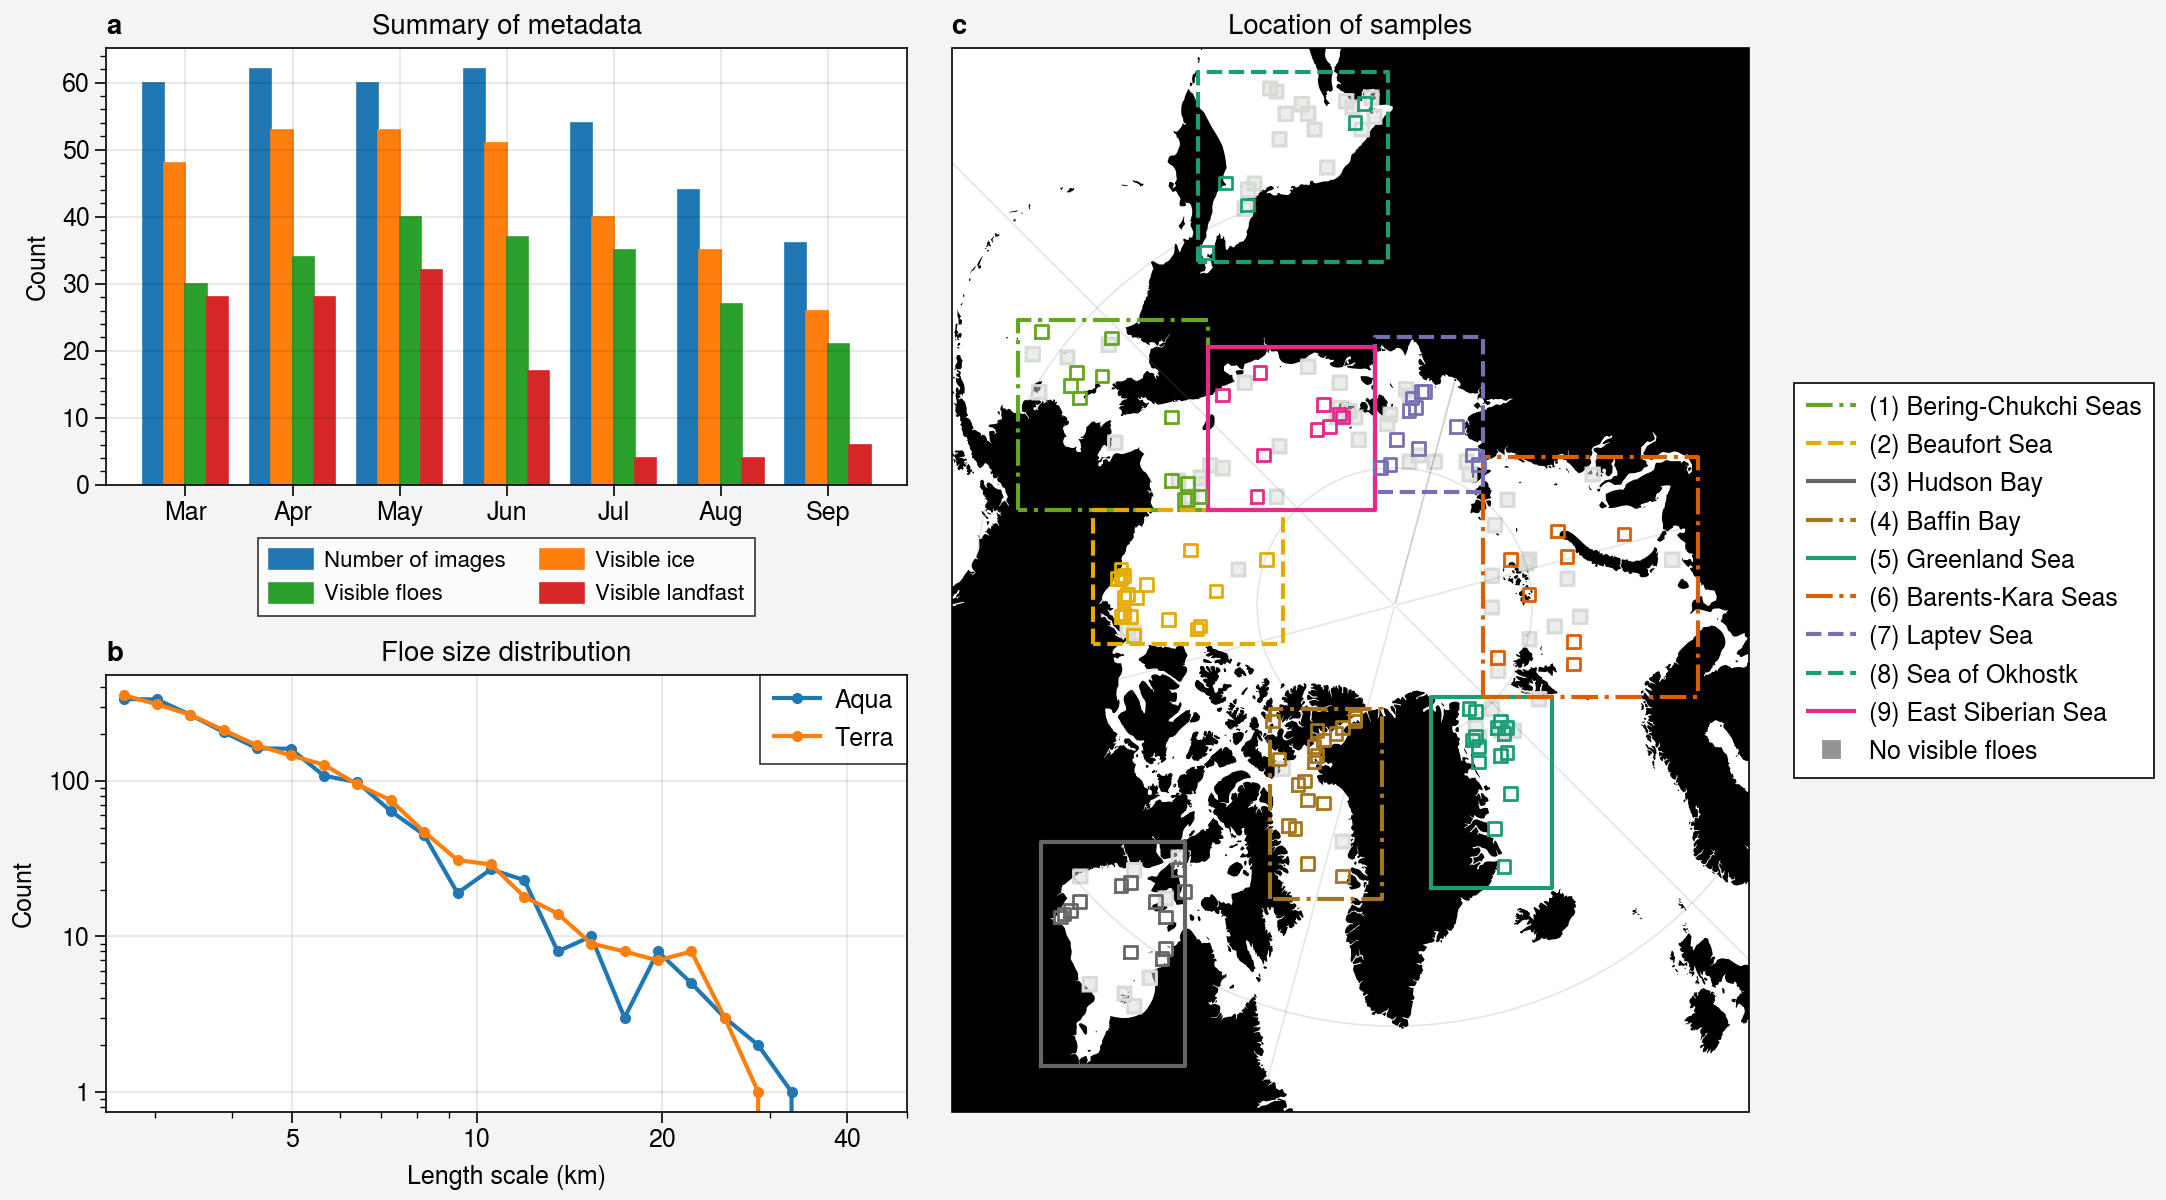

In [2]:
%run ../scripts/plot_dataset_summary.py

In [24]:
df_aqua_fsd['length_scale_km'] = np.sqrt(df_aqua_fsd['area'])*0.25
df_terra_fsd['length_scale_km'] = np.sqrt(df_terra_fsd['area'])*0.25

print('n total: ', len(df_aqua_fsd), len(df_terra_fsd))
print('n L < 5: ', len(df_aqua_fsd.loc[df_aqua_fsd.length_scale_km < 5, :]),
                        len(df_terra_fsd.loc[df_terra_fsd.length_scale_km < 5, :]))
print('n 5 < L < 10: ', len(df_aqua_fsd.loc[df_aqua_fsd.length_scale_km.between(5, 9.99), :]),
                        len(df_terra_fsd.loc[df_terra_fsd.length_scale_km.between(5, 9.99), :]))
print('n 10 < L: ', len(df_aqua_fsd.loc[df_aqua_fsd.length_scale_km > 10, :]),
                        len(df_terra_fsd.loc[df_terra_fsd.length_scale_km > 10, :]))

n total:  2505 2527
n L < 5:  2008 2000
n 5 < L < 10:  408 432
n 10 < L:  89 95


In [25]:
2008 + 408 + 89

2505

We find similar numbers of floes across both satellites, which shows consistency. Small floes are by far the most prevelant, with approximately 2,000 floes in the label dataset with that size range. Moderate floe sizes (5 to 10 km length scale) have about 400 floes from each satellite, and only about 90 are available larger than 10 km. 

In [18]:
pd.DataFrame( {'aqua': df_aqua_fsd.groupby('region').count()['label'], 
               'terra': df_terra_fsd.groupby('region').count()['label'] })

,aqua,terra
region,,
baffin_bay,580,576
barents_kara_seas,161,245
beaufort_sea,397,405
bering_chukchi_seas,169,209
east_siberian_sea,285,321
greenland_sea,324,312
hudson_bay,288,225
laptev_sea,291,228
sea_of_okhostk,10,6
